# Export a computation and verify its serving contract

CPU companion; no accelerator is required. TPU execution not validated.

- Serialize and reload a fixed-shape JAX inference computation.
- Test known values and changed requests independently.
- Distinguish export compatibility from service and edge-device readiness.

Your function works in the training process. Let’s make sure it also works after saving and reloading its inference computation. We’ll define one request shape, check a known prediction, and deliberately send an incompatible request. These checks give us a clear contract before adding a service around the model.

## The idea

Export packages a computation for a supported runtime. The consumer still needs input validation, preprocessing, output meaning and compatibility information. Separate the artifact boundary from the surrounding service.

## A serialized computation still needs an interface

The lesson exports a fixed float32 input of shape $(1,3)$ to an output of shape $(1,2)$. A Python function may accept a larger batch while that particular exported signature does not. The consumer must follow the artifact's declared contract.

Serialize, load the file again and call the restored computation on new inputs. Comparing only the original in-memory function does not test the exported bytes. Keep artifact hash, environment and tolerance with the result.

If preprocessing lives outside the export, version it alongside the model. A correct graph can still return wrong application results when the caller normalizes inputs differently. A local round trip does not automatically qualify another runtime, hardware target or version.

### Four different deployment boundaries

**Predict:** Which row is tested by the exported object alone?

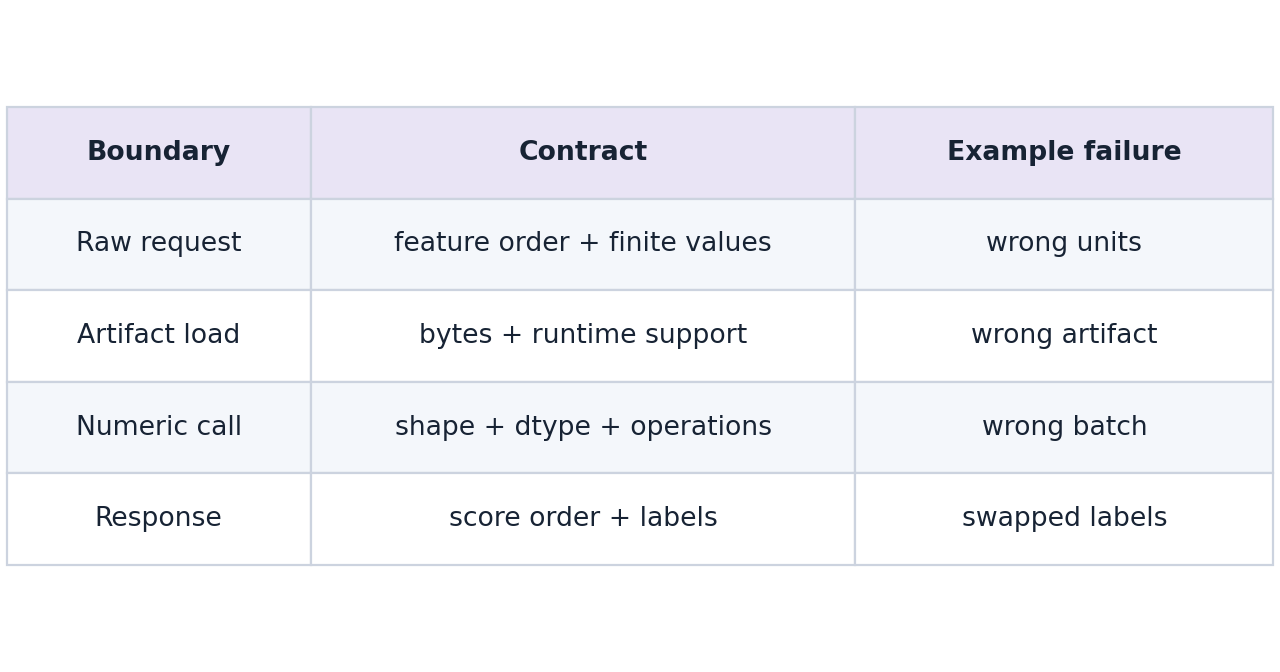

*Conceptual / analytic teaching diagram; not a recorded benchmark.*

Read top to bottom from the raw request to the response. Each row has a distinct contract and a distinct failure. The exported computation handles the numeric call; request fields, artifact identity and response meaning require surrounding checks. The fresh-process experiment exercises loading and calling under the installed CPU runtime.

### Pause and reason

What should happen to a request with the wrong feature count?

<details><summary>Compare your reasoning</summary>

Reject it at the interface with a clear explanation before inference. Silently reshaping may alter example meaning and does not make the request compatible with the exported signature.

</details>

## Freeze the inference boundary

The example closes over trained weights and bias, so those values become part of the exported computation. The single input is float32 $[1, 3]$; the output is float32 $[1, 2]$. A new weight version requires a new artifact here. For systems that pass weights as inputs, define and version those parameter signatures instead. Remove optimizer state and training-only behavior from this inference boundary.

## Fixed shapes are a deliberate constraint

A fixed batch-one signature simplifies the runtime contract. A batch of two is not accepted merely because the original Python expression supports it. JAX shape polymorphism is a separate export feature with its own constraints. Record permitted dimensions explicitly; an HTTP wrapper should reject malformed requests before invoking the computation.

## Verify the file, not the original function

Serialize, read back and deserialize before checking predictions. Then compare to both a manually known row and NumPy on new inputs. Record the JAX/jaxlib versions, platform, artifact hash, preprocessing and tolerance with the release. Exported calling conventions and supported platforms have compatibility rules; retain the environment instead of assuming a byte file runs everywhere.

## Choose a runtime after choosing an artifact

The local exported call still needs a compatible JAX runtime. For TensorFlow serving, investigate a supported jax2tf or Keras SavedModel route and retest outputs after conversion. For LiteRT, use its supported converter and runtime with explicit operator and dtype checks. ONNX Runtime needs a supported ONNX graph and execution provider. A format name alone says nothing about whether a target NPU can execute every operator.

## From local call to service

Place decoding, normalization, shape checks, inference and response encoding inside your request boundary. Set input size limits and concurrency limits. Measure cold initialization and warmed request latency separately; queueing and network time change the service result. The edge lesson extends this boundary to a single-device request. Autoscaling and a production server are outside this CPU artifact exercise.

## Separate serialized computation from the serving system

Export answers a specific question: can a staged computation be represented, loaded and called with the declared signature? It does not automatically include the request parser, feature names, normalization policy, output labels or service configuration. A fixed shape of $(1,3)$ says that the call expects one observation with three features; it says nothing about which physical measurements those features represent.

This example captures a particular set of weights and bias in the exported computation. The fresh-process experiment loads only the bytes and a request. It does not import the original inference function or retrain a model. Passing that test is stronger than calling the object that just produced the export, but it still checks the installed CPU runtime, not a different accelerator or another runtime's operator coverage.

## Define an inference-only computation

Create main.py in your lesson workspace and run it with the active course Python environment. Keep training out of the function and compute the known probe before exporting.

In [1]:
import tempfile
from pathlib import Path
import numpy as np
import jax
import jax.numpy as jnp
from jax import export
weights = jnp.array([[1., -2.], [.5, 1.], [-1., .25]], dtype=jnp.float32)
bias = jnp.array([.1, -.2], dtype=jnp.float32)
@jax.jit
def inference(x):
    return x @ weights + bias

np.testing.assert_allclose(inference(jnp.array([[1.,2.,-1.]], jnp.float32)), [[3.1,-.45]], atol=1e-6)


The probe returns $[3.1,-0.45]$. Preserve that independent expected value as you cross the serialization boundary.

## Declare the fixed input signature

Append this block to the same main.py and rerun the whole file. Stage the computation for a batch of one with three float32 features.

In [2]:
signature = jax.ShapeDtypeStruct((1, 3), jnp.float32)
artifact = export.export(inference)(signature)

assert artifact.in_avals[0].shape == (1,3)


The export has one input of shape $(1,3)$. A batch of two is a different contract; the failure experiment tests that rejection.

## Write bytes, reload and compare

Append this block to the same main.py and rerun the whole file. Serialize to disk and call the restored artifact on the same probe.

In [3]:
with tempfile.TemporaryDirectory() as folder:
    path = Path(folder) / "dense.jaxexport"
    path.write_bytes(artifact.serialize())
    restored = export.deserialize(path.read_bytes())
    sample = np.array([[1., 2., -1.]], np.float32)
    actual = np.asarray(restored.call(sample))
    np.testing.assert_allclose(actual, [[3.1, -.45]], atol=1e-6)
    print("Verified serialized bytes:", path.stat().st_size)


Verified serialized bytes: 1540


The output agrees with hand arithmetic. File size is recorded rather than hard-coded because the representation can change with the JAX version. Next, run the fresh-interpreter experiment.

## Run the example

In [4]:
import tempfile
from pathlib import Path
import numpy as np
import jax
import jax.numpy as jnp
from jax import export
weights = jnp.array([[1., -2.], [.5, 1.], [-1., .25]], dtype=jnp.float32)
bias = jnp.array([.1, -.2], dtype=jnp.float32)
@jax.jit
def inference(x):
    return x @ weights + bias
signature = jax.ShapeDtypeStruct((1, 3), jnp.float32)
artifact = export.export(inference)(signature)
with tempfile.TemporaryDirectory() as folder:
    path = Path(folder) / "dense.jaxexport"
    path.write_bytes(artifact.serialize())
    restored = export.deserialize(path.read_bytes())
    sample = np.array([[1., 2., -1.]], np.float32)
    actual = np.asarray(restored.call(sample))
    np.testing.assert_allclose(actual, [[3.1, -.45]], atol=1e-6)
    print("Verified serialized bytes:", path.stat().st_size)


Verified serialized bytes: 1396


Expected: The serialized artifact reloads and returns $[3.1, -0.45]$. File size depends on the JAX version.

## Serialization preserves the declared computation

Predict: Do the restored scores match the direct function?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
direct = np.asarray(inference(sample))
visual_data = {'kind': 'bar', 'labels': ['score 0', 'score 1'], 'ylabel': 'output score', 'series': [{'label': 'direct', 'y': direct[0].tolist()}, {'label': 'restored artifact', 'y': actual[0].tolist()}]}

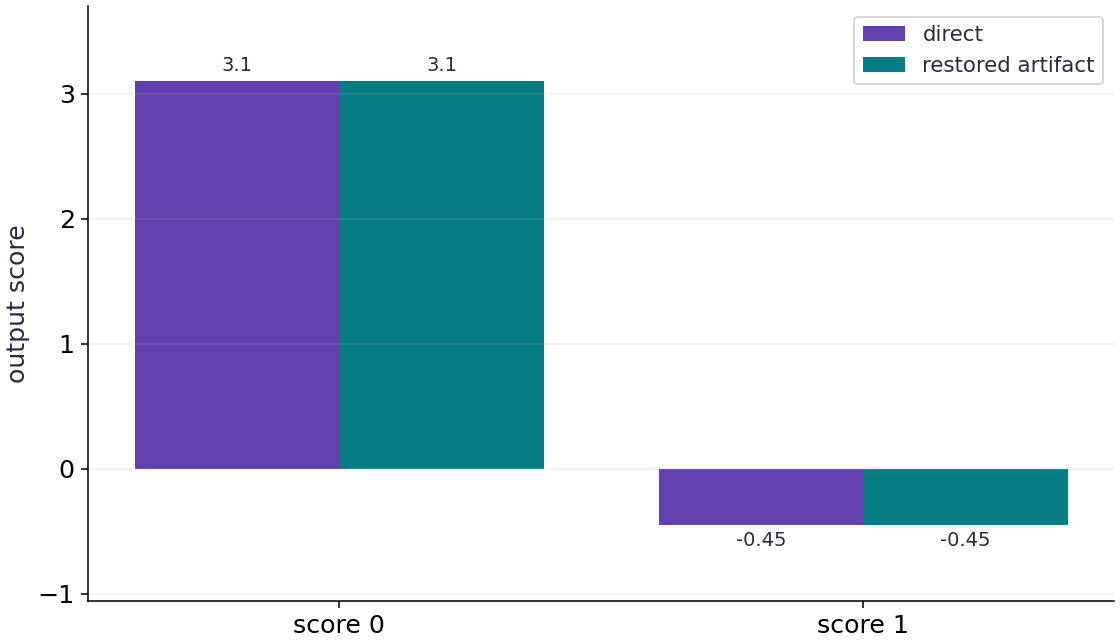

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

Each category is one output score. The paired bars compare the direct computation with the restored serialized artifact on the same input. Both give approximately $3.1$ for score $0$ and $-0.45$ for score $1$.

The matching heights show numerical agreement. The bars are adjacent, rather than one line hiding another. A negative second score is valid because these are raw outputs, not probabilities constrained to lie between zero and one.

### Connect it to the computation

This is the first behavior to check after serialization: does the restored computation preserve the result within the declared tolerance? The figure makes a coordinate-by-coordinate mismatch visible instead of reducing all outputs to one aggregate number.

The example exports a specific float32 input signature with shape $(1,3)$. Agreement for this case does not establish acceptance of arbitrary shapes or support in every serving runtime. Keep the signature and input preprocessing with the artifact, then expand parity checks to the cases your application actually needs.

## Reject the wrong batch

Predict: Does the exported signature accept two rows?

In [7]:
try:
    restored.call(np.ones((2, 3), np.float32))
except (ValueError, TypeError) as error:
    print("Rejected incompatible shape:", type(error).__name__)
else:
    raise AssertionError("Fixed batch-one contract was not enforced")


Rejected incompatible shape: ValueError


Expected: The incompatible shape is rejected.

A Python function being shape-generic does not make its fixed exported interface polymorphic.

## Load only the exported bytes in a fresh interpreter

Predict: Will the computation still work when the new process has no inference function or live parameter objects?

In [8]:
import json
import os
import subprocess
import sys
worker = """import json,sys
from pathlib import Path
import numpy as np
from jax import export
loaded = export.deserialize(Path(sys.argv[1]).read_bytes())
request = np.asarray(json.load(sys.stdin)['features'], dtype=np.float32)
print(json.dumps({'scores': np.asarray(loaded.call(request)).tolist()}, allow_nan=False))
"""
with tempfile.TemporaryDirectory() as directory:
    exported_path = Path(directory) / 'dense.jaxexport'
    exported_path.write_bytes(artifact.serialize())
    completed = subprocess.run([sys.executable, '-c', worker, str(exported_path)], input=json.dumps({'features': [[1.,2.,-1.]]}), text=True, capture_output=True, check=True, env=dict(os.environ, JAX_PLATFORMS='cpu'), timeout=60)
    worker_scores = json.loads(completed.stdout)['scores']
np.testing.assert_allclose(worker_scores, [[3.1, -.45]], atol=1e-6)
print('Fresh interpreter loaded bytes and matched the known scores.')


Fresh interpreter loaded bytes and matched the known scores.


Expected: The child process returns $[3.1,-0.45]$ using only the exported artifact and request.

The checked boundary is artifact bytes → installed JAX CPU runtime → scores. The worker has a JSON transport for the test, not a production web server. A separate deployment runtime requires its own receipt.

## Your exercise

Verify a new input $[-2, 0, 3]$ against an independent NumPy expression.

In [9]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [10]:
changed = np.array([[-2., 0., 3.]], np.float32)
expected = changed @ np.asarray(weights) + np.asarray(bias)
np.testing.assert_allclose(restored.call(changed), expected, atol=1e-6)
print("Changed exported request verified")

Changed exported request verified


## Validate a request before inference · Transfer

Write a host-side request checker that rejects nonfinite values and the wrong shape. Test a NaN input and a wrong feature count.

Hint: Validate shape and finiteness on the host before calling inference. Include a singleton batch, the wrong feature count and a NaN; specify which cases your serving signature permits.

In [11]:
# Write your attempt here.

## Reference reasoning

Validation belongs before the runtime call. A dtype cast alone neither verifies input shape nor rejects NaNs.

In [12]:
def validate_request(values):
    array = np.asarray(values, dtype=np.float32)
    if array.shape != (1, 3) or not np.isfinite(array).all():
        raise ValueError("expected finite float32 [1, 3]")
    return array
for invalid in ([[1., 2.]], [[1., float("nan"), 3.]]):
    try:
        validate_request(invalid)
    except ValueError:
        pass
    else:
        raise AssertionError("invalid input accepted")
np.testing.assert_allclose(restored.call(validate_request([[1.,2.,-1.]])), [[3.1,-.45]], atol=1e-6)


## Prove that request validation precedes exported inference · Transfer / diagnosis

Build a request wrapper that records how often inference runs. Reject both a malformed feature row and a nonfinite row before calling the exported computation. Then verify one valid request.

Hint: Increment the counter only after validation succeeds. An error message alone does not prove which boundary rejected the input.

In [13]:
# Write your attempt here.

## Reference reasoning

The wrapper tests ordering as well as acceptance. A service can satisfy an output check on valid inputs and still waste runtime work or fail unclearly on malformed requests.

In [14]:
inference_calls = [0]
def checked_prediction(values):
    array = validate_request(values)
    inference_calls[0] += 1
    return np.asarray(restored.call(array))
for invalid in ([[1., 2.]], [[1., float('inf'), 3.]]):
    try: checked_prediction(invalid)
    except ValueError: pass
    else: raise AssertionError('invalid request reached inference')
assert inference_calls[0] == 0
np.testing.assert_allclose(checked_prediction([[1.,2.,-1.]]), [[3.1,-.45]], atol=1e-6)
assert inference_calls[0] == 1
print('Invalid requests rejected before the one valid inference call.')


Invalid requests rejected before the one valid inference call.


## Checkpoint

What does a successful local export round trip prove?

1. The saved computation matches the tested CPU contract.
2. The file is an edge executable on every NPU.
3. An HTTP service now exists.

## Diagnose

A missing flatbuffers dependency prevents serialization: reinstall requirements-cpu.txt. A rejected input may be correct enforcement of your shape/dtype signature. Conversion success with output drift calls for intermediate-tensor comparison, preprocessing checks and evaluation on held-out examples.

## Evidence

Keep the export/reload code, version/platform manifest, known-output and changed-input checks, rejected-shape result, and the planned serving request boundary.

## Primary references

- [JAX export and serialization](https://docs.jax.dev/en/latest/export/export.html)
- [JAX shape polymorphism](https://docs.jax.dev/en/latest/export/shape_poly.html)
- [Keras inference export](https://keras.io/api/models/model_saving_apis/export/)